# Assessment 2: CNN Classification Performance on the FER-2013 Dataset
This notebook trains a CNN on the exact same shared split used by the ANN baseline.

## 1. Imports and Configuration
This section imports libraries and mirrors ANN training settings for fairness.

In [3]:
# Core utilities
import pathlib
import random

# Numerical work
import numpy as np

# Deep learning framework
import tensorflow as tf

# Plotting
import matplotlib.pyplot as plt

# Metrics + class imbalance handling
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Reproducibility / Fairness
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Shared split created by ANN notebook
SPLITS_PATH = pathlib.Path("./fer-2013_splits.npz")

# Same hyperparameters as ANN for fairness
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3

## 2. Load Shared Splits
This section loads the saved FER-2013 train/val/test arrays for a fair test.

In [4]:
# Ensure the shared split exists
if not SPLITS_PATH.exists():
    raise FileNotFoundError(
        "Shared split not found. Run fer2013-ann.ipynb first to create fer2013_splits.npz"
    )

# Load shared arrays
splits = np.load(SPLITS_PATH, allow_pickle=True)

X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val     = splits["X_val"], splits["y_val"]
X_test, y_test   = splits["X_test"], splits["y_test"]

class_names = splits["class_names"].tolist()
num_classes = len(class_names)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print("Classes:", class_names)

Train: (22967, 48, 48, 1)
Val:   (5742, 48, 48, 1)
Test:  (5583, 48, 48, 1)
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 3. Compute Class Weights
This section computes the same balanced class weights used in the ANN notebook.

In [5]:
# Compute balanced weights from training labels
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dict for Keras
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)

Class weights: {0: 1.0265957446808511, 1: 9.401146131805158, 2: 1.0012206286237413, 3: 0.5684338184338185, 4: 0.8260322255790534, 5: 0.849120082815735, 6: 1.2932597556168703}


## 4. Build and Compile CNN
This section defines a small CNN with light augmentation for FER-2013 faces.

In [6]:
# Data augmentation helps FER generalisation (faces vary a lot)
data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])

def build_cnn(num_classes):
    """
    Teaching-level CNN:
    - Convolutions learn local facial features (eyes, mouth corners, brows).
    - Pooling increases translation invariance.
    - Augmentation improves robustness to pose/lighting.
    """
    inputs = tf.keras.layers.Input(shape=(48, 48, 1))
    x = data_augment(inputs)

    # Conv block 1
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Conv block 2
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Conv block 3
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Classifier head
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

# Build CNN
cnn = build_cnn(num_classes)

# Compile with same optimiser/lr as ANN
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

2025-11-24 17:31:47.053866: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-11-24 17:31:47.054276: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-11-24 17:31:47.054944: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-11-24 17:31:47.055092: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-24 17:31:47.056116: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train CNN
This section trains the CNN under the same regime as the ANN to isolate architecture effects.

In [7]:
# Early stopping to prevent overfitting and keep training comparable
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]

# Train CNN with class weights
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/40


2025-11-24 17:31:52.018385: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.1159 - loss: 1.9447 - val_accuracy: 0.2140 - val_loss: 1.8612
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.1937 - loss: 1.8959 - val_accuracy: 0.2652 - val_loss: 1.8029
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.2389 - loss: 1.8259 - val_accuracy: 0.3093 - val_loss: 1.7198
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.2728 - loss: 1.7856 - val_accuracy: 0.3492 - val_loss: 1.6615
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.3049 - loss: 1.7403 - val_accuracy: 0.3784 - val_loss: 1.6052
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.3286 - loss: 1.7096 - val_accuracy: 0.4060 - val_loss: 1.5662
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.3513 - loss: 1.6800 - val_accuracy: 0.4225 - val_loss: 1.5429
Epoch 8/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.3598 - loss: 1.6660 - val_accurac

## 6. Evaluate CNN
This section reports CNN test performance and a confusion matrix for direct ANN comparison.

CNN Test Accuracy: 0.4713
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

       angry       0.06      0.44      0.10       116
     disgust       0.01      1.00      0.01         1
        fear       0.42      0.18      0.26      1024
       happy       0.76      0.66      0.71      1636
     neutral       0.58      0.36      0.44      1229
         sad       0.29      0.45      0.35       746
    surprise       0.71      0.64      0.68       831

    accuracy                           0.47      5583
   macro avg       0.40      0.53      0.36      5583
weighted avg       0.57      0.47      0.50      5583



<Figure size 700x700 with 0 Axes>

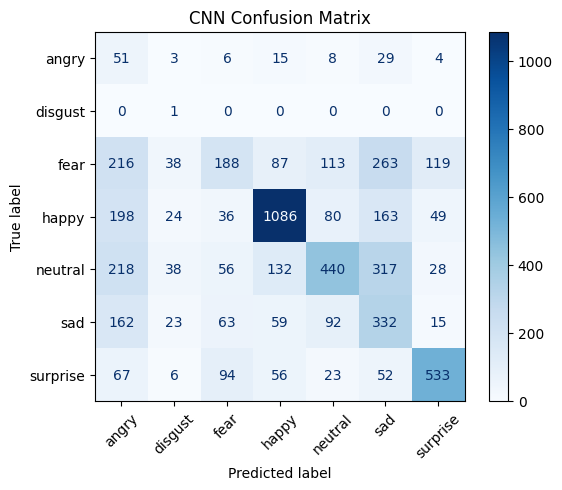

In [8]:
# Final test evaluation (held-out)
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.4f}")

# Predict and convert probabilities to labels
y_pred = np.argmax(cnn.predict(X_test), axis=1)

# Per-class report
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

plt.figure(figsize=(7, 7))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("CNN Confusion Matrix")
plt.show()